# Modeling: MultiModal AI — Homework 4
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore **Reinforcement Learning for Vision-Language Models**. Specifically, you will implement and train a VLM using **Group Relative Policy Optimization (GRPO)**, a recent RL algorithm for aligning language models with reward signals.

---

## Environment Setup

Go to the top menu:
Runtime → Change runtime type → Hardware accelerator → Choose **"A100"**

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:
https://colab.research.google.com/signup

# Part 2: Implementing and Training GRPO (100 points)

# Part 1: Reading & Reflection (20 points)

### Required Reading

1. [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300) (Sections 1, 3, and 4)

2. [The Illustrated GRPO](https://abderrahmanskiredj.github.io/the-illustrated-grpo/) (Full post)

---

### Questions

1. **GRPO vs PPO**: GRPO removes the need for a learned value function (critic). Explain how GRPO estimates the baseline for advantage computation without a critic, and what tradeoffs this introduces.

2. **Reward Design**: Discuss the difference between using a learned reward model vs. a rule-based reward function (e.g., checking if an answer matches ground truth). What are the risks of reward hacking in each case?

3. **SFT vs. GRPO**: In Homework 3, you fine-tuned a VLM using supervised fine-tuning (SFT) with LoRA. Compare the SFT approach with GRPO training: how does the training signal differ, and when would each be preferred?

**Q1: GRPO vs PPO**

GRPO eliminates the need for a learned value function by using a group-based baseline instead. For each prompt, the policy generates G completions and receives a scalar reward for each. The baseline is simply the mean reward across the group, and the advantage for each completion is computed as its reward minus this mean, normalized by the group standard deviation. This is mathematically an unbiased estimate of the value function without requiring a separate critic network.
The tradeoff is statistical stability. A learned critic can in principle provide a lower-variance baseline because it generalizes across the entire training distribution, whereas the group-based estimate is computed from only G samples per prompt. When G is small, this estimate can be noisy, leading to higher-variance gradient updates. However, the memory and compute savings from removing the critic are substantial enough that GRPO remains more practical for large-scale training.

**Q2: Reward Design**

A learned reward model is trained on human preference data to score outputs along a continuous scale, capturing nuanced quality judgments. However, it is vulnerable to reward hacking: the policy can find outputs that score highly according to the reward model without actually being correct or useful, exploiting distributional gaps between the reward model's training data and the policy's outputs. This is sometimes called reward model overoptimization.
A rule-based reward function such as exact match against ground truth is immune to this form of hacking because it cannot be fooled by outputs that merely look plausible. However, it introduces its own risk: the policy may learn to game the specific rule, for example by always outputting the most common label, or by formatting its answer to match the extraction pattern without genuine reasoning. Rule-based rewards also provide no gradient signal for partially correct answers, which can slow down learning in the early stages of training.

**Q3: SFT vs GRPO**

In SFT, the training signal is the cross-entropy loss between the model's output distribution and the ground truth answer. The model is directly told what the correct output is at every token, which makes learning efficient but constrains the model to imitate the training data rather than explore alternative valid responses.
In GRPO, there is no ground truth token sequence provided during training. Instead, the model generates its own completions, receives a reward signal, and updates its policy to increase the probability of high-reward completions relative to low-reward ones within each group. The training signal is therefore comparative rather than absolute.
SFT is preferred when high-quality labeled data is available and the task has a well-defined correct output, such as action recognition or image captioning. GRPO is preferred when the desired behavior is harder to specify as a fixed target, such as mathematical reasoning or multi-step problem solving, where the model benefits from exploring different solution paths and being rewarded for correctness rather than surface-level imitation. In the context of this homework, GRPO encourages the model to develop step-by-step reasoning before committing to an answer, a behavior that SFT cannot easily instill without explicit chain-of-thought annotations in the training data.

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.
- The **secret word** displayed by your verification cell.

---

In [ ]:
!pip install transformers accelerate bitsandbytes pillow torch torchvision trl peft datasets gdown qwen-vl-utils -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 73
cipher_bytes = [14, 27, 25, 6, 105, 32, 58, 105, 8, 37, 37, 105, 16, 38, 60, 105, 7, 44, 44, 45]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = cipher ^ KEY
    secret_word = "".join(chr(c) for c in decoded.cpu().tolist())
    print(f"\nGPU check passed! Secret word: {secret_word}")
else:
    print("\nNo GPU detected. Please switch to an A100 runtime.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 69.3 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB

GPU check passed! Secret word: GRPO is All You Need


# Problem 2: Prepare Your Dataset (10 points)

You will **reuse the dataset you prepared in Homework 3** (or Homework 1/2). The data format remains the same:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   └── ...
└── data.jsonl
```

Each line in `data.jsonl` should be a JSON object with:

```json
{
  "image": "images/1.jpg",
  "question": "What animal is in this image?",
  "answer": "cat"
}
```

**If you do not have your own dataset**, the default Google Drive link below will download a small example dataset so you can complete the homework. You will lose some points for not using your own data, but you can still finish every problem.

As in HW3, you should have a **train/test split**. The test images should not be used during training.

In HW3, you used supervised fine-tuning (SFT), which directly trains the model to produce the correct answer. In this homework, we use **reinforcement learning**: the model generates its own answers, receives a reward signal, and updates its policy to maximize future reward.

To enable the RL training loop, we append an instruction after each user question asking the model to **think step-by-step** and then place its final answer after `Answer:`. This structured output lets us automatically extract and evaluate the model's prediction.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2, json, shutil
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

VIDEO_DIR = "/content/drive/MyDrive/utd_mhad"

ACTION_LABELS = {
    1: "swipe left", 2: "swipe right", 3: "wave", 4: "clap",
    5: "throw", 6: "arm cross", 7: "basketball shoot", 8: "draw x",
    9: "draw circle clockwise", 10: "draw circle counter clockwise",
    11: "draw triangle", 12: "bowling", 13: "boxing", 14: "baseball swing",
    15: "tennis swing", 16: "arm curl", 17: "tennis serve", 18: "push",
    19: "knock", 20: "catch", 21: "pickup and throw", 22: "jog",
    23: "walk", 24: "sit to stand", 25: "stand to sit", 26: "lunge",
    27: "squat"
}

OUT_DIR = Path("/content/mmai-data")
IMG_DIR = OUT_DIR / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

records = []
for avi_path in sorted(Path(VIDEO_DIR).rglob("*.avi")):
    parts = avi_path.stem.split("_")
    try:
        action_id = int(parts[0][1:])
    except ValueError:
        continue
    label = ACTION_LABELS.get(action_id, "unknown")
    cap = cv2.VideoCapture(str(avi_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        continue
    img_name = f"{avi_path.stem}.jpg"
    cv2.imwrite(str(IMG_DIR / img_name), frame)
    records.append({
        "image": f"images/{img_name}",
        "question": "What action is the person performing?",
        "answer": label
    })

with open(OUT_DIR / "data.jsonl", "w") as f:
    for r in records:
        f.write(json.dumps(r) + "\n")

print(f"Done! {len(records)} samples saved.")

# Save zip to Drive for reuse
shutil.make_archive('/content/mmai-data', 'zip', '/content', 'mmai-data')
shutil.copy('/content/mmai-data.zip', '/content/drive/MyDrive/mmai-data.zip')
print("Zip saved to Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done! 861 samples saved.
Zip saved to Drive!


In [ ]:
import os, shutil, zipfile, json
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# If you do not have your own dataset, leave the default URL.
# The default dataset is a small example so you can still
# complete the homework.

GDRIVE_SHARE_URL: str = ""

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_ROOT = Path("mmai-data")
ZIP_PATH  = Path("mmai-data.zip")

if not DATA_ROOT.exists():
    if GDRIVE_SHARE_URL:
        import gdown
        gdown.download(GDRIVE_SHARE_URL, str(ZIP_PATH), quiet=False, fuzzy=True)
        with zipfile.ZipFile(ZIP_PATH) as zf:
            zf.extractall(".")
        ZIP_PATH.unlink(missing_ok=True)
    else:
        print("Please set GDRIVE_SHARE_URL above, or manually upload mmai-data/ folder.")

# Verify dataset
if DATA_ROOT.exists():
    jsonl_path = DATA_ROOT / "data.jsonl"
    with open(jsonl_path) as f:
        lines = [json.loads(l) for l in f if l.strip()]
    print(f"Dataset loaded: {len(lines)} samples")
    print(f"Sample: {lines[0]}")
else:
    print("Dataset not found. Please upload your data.")

Dataset loaded: 861 samples
Sample: {'image': 'images/a1_s1_t1_color.jpg', 'question': 'What action is the person performing?', 'answer': 'swipe left'}


# Problem 3: Understanding GRPO (15 points)

Before implementing GRPO, let us walk through the key ideas.

## Background: From PPO to GRPO

Standard RLHF methods like **PPO (Proximal Policy Optimization)** require four models: a policy, a reference model, a reward model, and a value model (critic). GRPO simplifies this by **removing the value model entirely**, using the group of completions generated for the same prompt to estimate a baseline.

## The GRPO Algorithm

Given a prompt $q$, we sample $G$ completions $\{o_1, o_2, \ldots, o_G\}$ from the current policy $\pi_\theta$. Each completion receives a reward $r_i$.

### Step 1: Compute the Group Advantage

$$\hat{A}_i = \frac{r_i - \text{mean}(\mathbf{r})}{\text{std}(\mathbf{r}) + \epsilon}$$

where $\mathbf{r} = [r_1, \ldots, r_G]$ are the rewards for all completions of the same prompt.

### Step 2: Clipped Surrogate Loss

$$L_{\text{GRPO}}(\theta) = -\frac{1}{G} \sum_{i=1}^{G} \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \min\left( \rho_{i,t} \hat{A}_i,\ \text{clip}(\rho_{i,t},\ 1 - \varepsilon,\ 1 + \varepsilon) \hat{A}_i \right)$$

where $\rho_{i,t} = \frac{\pi_\theta(o_{i,t} | q, o_{i,<t})}{\pi_{\theta_{\text{old}}}(o_{i,t} | q, o_{i,<t})}$ is the importance sampling ratio.

### Step 3 (Optional): KL Regularization

$$L_{\text{total}} = L_{\text{GRPO}} + \beta \cdot \mathbb{D}_{\text{KL}}[\pi_\theta \| \pi_{\text{ref}}]$$

---

## Questions to Answer:

1. In your own words, explain why the group-based advantage normalization works as a baseline. What happens when all $G$ completions for a prompt receive the same reward?

2. What is the role of the clipping term $\text{clip}(\rho_{i,t}, 1-\varepsilon, 1+\varepsilon)$? What could go wrong during training without it?

**Q1**

The group-based advantage works as a baseline because it provides a relative comparison signal without requiring a learned critic. By normalizing each completion's reward against the mean and standard deviation of the group, the model learns not whether an answer is good in absolute terms, but whether it is better or worse than the other completions generated for the same prompt. This is sufficient to update the policy in the right direction: completions above the group mean get positive advantage and are reinforced, while completions below the mean get negative advantage and are suppressed.
When all G completions for a prompt receive the same reward, the mean equals every individual reward, so every advantage is exactly zero. This means the policy gradient for that prompt is zero and no parameter update occurs.

**Q2**

The clipping term restricts the ratio between the new policy and the old policy to the range [1-ε, 1+ε]. This prevents any single gradient update from changing the policy too drastically. Without clipping, a completion with a large positive advantage could cause the policy to shift aggressively toward that output, potentially overshooting the optimum and destabilizing training.

# Problem 4: Implement the GRPO Advantage Computation (25 points)

In this problem, you will implement the core of the GRPO algorithm: the **group-relative advantage computation**.

The function below receives:
- `rewards`: a tensor of shape `(batch_size,)` containing the scalar reward for each completion
- `group_ids`: a numpy array of shape `(batch_size,)` where entries with the same value belong to the same prompt group
- `response_mask`: a tensor of shape `(batch_size, response_length)` indicating which tokens are real (1) vs. padding (0)

Your task is to fill in the parts marked `# TODO`. Unit tests will run automatically to verify your implementation.

---

### Example

```python
# Two prompts, each with 2 completions (G=2), response length = 3
rewards    = torch.tensor([1.0, 3.0, 2.0, 4.0])
group_ids  = np.array([0, 0, 1, 1])         # samples 0,1 share prompt 0; samples 2,3 share prompt 1
mask       = torch.ones(4, 3)

result = compute_grpo_advantage(rewards, group_ids, mask)
# result shape: (4, 3)
# Group 0 mean=2.0, std=1.41 → sample 0 advantage ≈ -0.71, sample 1 advantage ≈ +0.71
# Group 1 mean=3.0, std=1.41 → sample 2 advantage ≈ -0.71, sample 3 advantage ≈ +0.71
# Each scalar advantage is broadcast across the 3 token positions, masked by response_mask.
```

In [ ]:
import torch
import numpy as np
from collections import defaultdict

def compute_grpo_advantage(
    rewards: torch.Tensor,
    group_ids: np.ndarray,
    response_mask: torch.Tensor,
    epsilon: float = 1e-6,
    scale_by_std: bool = True,
) -> torch.Tensor:
    """
    Compute group-relative advantages for GRPO.

    Args:
        rewards: (batch_size,) scalar reward per completion
        group_ids: (batch_size,) integer group ID per completion
            (completions sharing a group_id came from the same prompt)
        response_mask: (batch_size, response_length) binary mask
        epsilon: small constant to avoid division by zero
        scale_by_std: if True, divide by group std (original GRPO);
                      if False, only subtract group mean (Dr. GRPO variant)

    Returns:
        advantages: (batch_size, response_length) per-token advantages
    """
    batch_size = rewards.shape[0]
    advantages = torch.zeros_like(rewards)

    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    # Step 1: Group the rewards by group_ids.
    # Build a mapping from each group ID to the list of reward values
    # for all completions in that group.
    id_to_rewards = defaultdict(list)
    # TODO: iterate over the batch and populate id_to_rewards

    # Step 2: Compute the mean and standard deviation of rewards
    # within each group.
    # Edge case: if a group has only one sample, there is no variance.
    # Set std to 1.0 so that the advantage becomes (r - r) / 1 = 0.
    id_to_mean = {}
    id_to_std = {}
    # TODO: iterate over id_to_rewards and compute mean/std for each group

    # Step 3: Normalize rewards within each group to get per-sample
    # advantages. If scale_by_std is True (standard GRPO), compute:
    #   A_i = (r_i - mean) / (std + epsilon)
    # If scale_by_std is False (Dr. GRPO variant), only subtract the
    # group mean without dividing by std:
    #   A_i = r_i - mean
    # TODO: compute advantages[i] for each sample

    # Step 1: Group rewards by group_id
    id_to_rewards = defaultdict(list)
    for i in range(batch_size):
        id_to_rewards[group_ids[i]].append(rewards[i])

    # Step 2: Compute mean and std per group
    id_to_mean = {}
    id_to_std = {}
    for gid, group_rewards in id_to_rewards.items():
        group_tensor = torch.stack(group_rewards)
        id_to_mean[gid] = group_tensor.mean()
        if len(group_rewards) == 1:
            id_to_std[gid] = torch.tensor(1.0)
        else:
            id_to_std[gid] = group_tensor.std()

    # Step 3: Compute normalized advantage per sample
    for i in range(batch_size):
        gid = group_ids[i]
        mean = id_to_mean[gid]
        std = id_to_std[gid]
        if scale_by_std:
            advantages[i] = (rewards[i] - mean) / (std + epsilon)
        else:
            advantages[i] = rewards[i] - mean

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================

    # Step 4: Broadcast scalar advantages to token level.
    per_token_advantages = advantages.unsqueeze(-1) * response_mask

    return per_token_advantages


# ==================== Unit Tests ====================
# Do NOT modify this section.

def test_grpo_advantage():
    print("Running tests...")

    # Test 1: Basic two-group case
    rewards = torch.tensor([1.0, 3.0, 2.0, 4.0])
    group_ids = np.array([0, 0, 1, 1])
    mask = torch.ones(4, 5)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv.shape == (4, 5), f"Expected shape (4, 5), got {adv.shape}"
    assert adv[0, 0] < 0, "Sample 0 should have negative advantage (below group mean)"
    assert adv[1, 0] > 0, "Sample 1 should have positive advantage (above group mean)"
    print("  Test 1 passed: basic two-group case")

    # Test 2: Single-sample group should have zero advantage
    rewards = torch.tensor([5.0, 1.0, 3.0])
    group_ids = np.array([0, 1, 1])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv[0], torch.zeros(4)), "Single-sample group should have zero advantage"
    print("  Test 2 passed: single-sample group")

    # Test 3: Masking zeros out padded positions
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.tensor([[1, 1, 0, 0], [1, 1, 1, 0]], dtype=torch.float)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv[0, 2] == 0.0 and adv[1, 3] == 0.0, "Padded positions should be 0"
    assert adv[1, 0] != 0.0, "Non-padded position should be non-zero"
    print("  Test 3 passed: masking")

    # Test 4: Dr. GRPO variant (no std scaling)
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.ones(2, 3)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=False)
    assert torch.allclose(adv[0], torch.full((3,), -1.0)), f"Expected -1.0, got {adv[0]}"
    assert torch.allclose(adv[1], torch.full((3,), 1.0)), f"Expected +1.0, got {adv[1]}"
    print("  Test 4 passed: Dr. GRPO variant")

    # Test 5: Uniform rewards -> zero advantage
    rewards = torch.tensor([2.0, 2.0, 2.0])
    group_ids = np.array([0, 0, 0])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv, torch.zeros(3, 4), atol=1e-5), "Same rewards should give zero advantage"
    print("  Test 5 passed: uniform rewards")

    print("\nAll tests passed!")

test_grpo_advantage()

Running tests...
  Test 1 passed: basic two-group case
  Test 2 passed: single-sample group
  Test 3 passed: masking
  Test 4 passed: Dr. GRPO variant
  Test 5 passed: uniform rewards

All tests passed!


# Problem 5: Define Reward Functions (15 points)

Now you will define the reward functions used to train the model. We use two simple, rule-based rewards:

1. **Accuracy Reward** (binary): Does the model's answer match the ground truth? We extract the answer from after `Answer:` and compare.

2. **Format Reward** (binary): Did the model use the `Answer:` format at all? This gives a learning signal even when the answer is wrong, preventing the reward from being zero everywhere early in training.

Fill in the parts marked `# TODO`. The `extract_answer` helper is provided for you.

---

### Reward Function API

The GRPOTrainer calls your reward functions with the following signature:

```python
def my_reward_func(completions: list, **kwargs) -> list:
```

**`completions`** is a list of model completions, one per sample. Each completion is a
single-element list containing a message dict:

```python
# completions example (batch of 3):
[
    [{"role": "assistant", "content": "Let me think step by step...\nAnswer: cat"}],
    [{"role": "assistant", "content": "I see a vehicle.\nAnswer: truck"}],
    [{"role": "assistant", "content": "This looks like a park."}],
]
```

To get the text, use `completion[0]["content"]`.

**`**kwargs`** contains any extra dataset columns. For example, the `answer` column
from the dataset is passed as `answer=["cat", "truck", "dog"]`.

**Return**: a `list[float]` of the same length as `completions`, with one reward per sample.

In [ ]:
import re

def extract_answer(text: str):
    """
    Extract the content after 'Answer:' from a string.
    Returns None if 'Answer:' is not found.

    Example:
        >>> extract_answer("I see a furry animal.\\nAnswer: cat")
        'cat'
        >>> extract_answer("No answer marker here")
        None
    """
    match = re.search(r"Answer:\s*(.+)", text, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return None


def accuracy_reward(completions: list, answer: list, **kwargs) -> list:
    """
    Reward function: 1.0 if the extracted answer matches ground truth, 0.0 otherwise.

    Args:
        completions: list of completions, each is [{"role": "assistant", "content": str}]
            Example: [[{"role": "assistant", "content": "Reasoning...\\nAnswer: cat"}],
                       [{"role": "assistant", "content": "I think...\\nAnswer: dog"}]]
        answer: list of ground-truth answer strings (from dataset column)
            Example: ["cat", "dog"]

    Returns:
        list[float]: one reward per sample
            Example: [1.0, 1.0]
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    # rewards = []
    # TODO: for each (completion, ground_truth) pair, extract the
    # predicted answer and compare it to the ground truth.
    # Append 1.0 if they match, 0.0 otherwise.

    rewards = []
    for completion, ground_truth in zip(completions, answer):
        text = completion[0]["content"]
        predicted = extract_answer(text)
        if predicted is not None and predicted.lower().strip() == ground_truth.lower().strip():
            rewards.append(1.0)
        else:
            rewards.append(0.0)

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


def format_reward(completions: list, **kwargs) -> list:
    """
    Reward function: 1.0 if the completion contains 'Answer:', 0.0 otherwise.

    Args:
        completions: list of completions, each is [{"role": "assistant", "content": str}]
            Example: [[{"role": "assistant", "content": "Answer: hello"}],
                       [{"role": "assistant", "content": "no answer marker here"}]]

    Returns:
        list[float]: one reward per sample
            Example: [1.0, 0.0]
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    # rewards = []
    # TODO: for each completion, check if extract_answer returns
    # a non-None value. Append 1.0 if it does, 0.0 otherwise.

    rewards = []
    for completion in completions:
        text = completion[0]["content"]
        if extract_answer(text) is not None:
            rewards.append(1.0)
        else:
            rewards.append(0.0)

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


# ==================== Unit Tests ====================

def test_reward_functions():
    print("Running reward function tests...")

    assert extract_answer("I think it is a dog. Answer: dog") == "dog"
    assert extract_answer("No answer marker here") is None
    print("  extract_answer: passed")

    completions_conv = [
        [{"role": "assistant", "content": "Let me think... Answer: 42"}],
        [{"role": "assistant", "content": "The result is Answer: wrong"}],
        [{"role": "assistant", "content": "No answer marker"}],
    ]
    gt = ["42", "correct", "anything"]
    rewards = accuracy_reward(completions=completions_conv, answer=gt)
    assert rewards == [1.0, 0.0, 0.0], f"Expected [1.0, 0.0, 0.0], got {rewards}"
    print("  accuracy_reward: passed")

    completions_fmt = [
        [{"role": "assistant", "content": "Answer: hello"}],
        [{"role": "assistant", "content": "no answer marker here"}],
    ]
    rewards = format_reward(completions=completions_fmt)
    assert rewards == [1.0, 0.0], f"Expected [1.0, 0.0], got {rewards}"
    print("  format_reward: passed")

    print("\nAll reward function tests passed!")

test_reward_functions()

Running reward function tests...
  extract_answer: passed
  accuracy_reward: passed
  format_reward: passed

All reward function tests passed!


# Problem 6: Build the Training Dataset for GRPO (10 points)

Now we convert your `data.jsonl` into the format expected by the TRL `GRPOTrainer`.

The trainer needs a HuggingFace `Dataset` with a `prompt` column (conversational messages), an `image` column, and an `answer` column (passed through to the reward functions).

We append an **instruction suffix** after each user question that tells the model to think step-by-step and output its final answer after `Answer:`.

In [ ]:
import json
from pathlib import Path
from PIL import Image
from datasets import Dataset

DATA_ROOT = Path("mmai-data")

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer as a single word on the last line after \"Answer:\". "
    "For example:\nI can see a furry animal curled up on the couch...\nAnswer: cat"
)

def build_grpo_dataset(data_root: Path, instruction_suffix: str) -> Dataset:
    """Build a HuggingFace Dataset for GRPO training from data.jsonl."""
    jsonl_path = data_root / "data.jsonl"
    with open(jsonl_path) as f:
        raw_data = [json.loads(line) for line in f if line.strip()]

    samples = {"prompt": [], "image": [], "answer": []}

    for entry in raw_data:
        img_path = data_root / entry["image"]
        if not img_path.exists():
            print(f"Warning: image not found: {img_path}")
            continue

        image = Image.open(img_path).convert("RGB")

        prompt = [
            {"role": "user", "content": entry["question"] + instruction_suffix},
        ]

        samples["prompt"].append(prompt)
        samples["image"].append(image)
        samples["answer"].append(entry["answer"])

    dataset = Dataset.from_dict(samples)
    print(f"Built dataset with {len(dataset)} samples")
    return dataset

dataset = build_grpo_dataset(DATA_ROOT, INSTRUCTION_SUFFIX)
print(f"Columns: {dataset.column_names}")
print(f"Sample prompt structure: {[msg['role'] for msg in dataset[0]['prompt']]}")

Built dataset with 861 samples
Columns: ['prompt', 'image', 'answer']
Sample prompt structure: ['user']


# Problem 7: Train with GRPO (20 points)

Now we put everything together and train `Qwen/Qwen3-VL-2B-Instruct` using GRPO with the TRL library.

Note that for simplicity, we use vanilla implementation from trl package for the training here, so you shuld be able to run the cell below to train the model even if you don't have `compute_grpo_advantage` completed.

### Instructions

1. Run the training cell below with the default settings first.
2. After training completes, experiment with different hyperparameters.
3. Document which settings worked best and why.

| Parameter | Description |
|-----------|-------------|
| `num_generations` | Completions per prompt (G in the paper) |
| `max_completion_length` | Max tokens to generate |
| `max_steps` | Maximum number of training steps |
| `learning_rate` | Optimizer step size |
| `epsilon` | Clipping range for surrogate objective |
| `temperature` | Sampling temperature |
| `beta` | KL penalty (0.0 = disabled) |

In [ ]:
import torch
from trl import GRPOTrainer, GRPOConfig
from peft import LoraConfig

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

# GRPO hyperparameters
NUM_GENERATIONS = 2          # G: completions per prompt
MAX_COMPLETION_LENGTH = 128  # max tokens per completion
LEARNING_RATE = 1e-5
MAX_STEPS = 100              # max training steps
BATCH_SIZE = 1               # keep at 1 for memory
EPSILON = 0.2                # clipping range
TEMPERATURE = 0.9            # sampling temperature
BETA = 0.0                   # KL penalty (0 = disabled)

# LoRA hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET = ["q_proj", "v_proj", "k_proj", "o_proj"]

OUTPUT_DIR = "grpo-output"

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    num_generations=NUM_GENERATIONS,
    generation_batch_size=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    learning_rate=LEARNING_RATE,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    epsilon=EPSILON,
    temperature=TEMPERATURE,
    beta=BETA,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=1,
    save_steps=100,
    seed=42,
    log_completions=True,
)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    task_type="CAUSAL_LM",
)

trainer = GRPOTrainer(
    model=MODEL_ID,
    reward_funcs=[accuracy_reward, format_reward],
    args=training_args,
    train_dataset=dataset,
    peft_config=peft_config,
)

print(f"Model: {MODEL_ID}")
print(f"Training samples: {len(dataset)}, Generations/prompt: {NUM_GENERATIONS}")
print(f"LoRA rank={LORA_R}, alpha={LORA_ALPHA}")
print("Starting GRPO training...")

trainer.train()

print("Training complete!")
trainer.save_model(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

...

╭──────────────────────────────────────────────────── Step 98 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person is standing in     │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ front of a whiteboard and     │                 │               │           │ │
│ │ performing?                   │ appears to be speaking or     │                 │               │           │ │
│ │                               │ presenting, as they are       │                 │               │           │ │
│ │ First, think through your     │ gesturing with their hands.   │                 │               │           │ │
│ │ reasoning step by step. Then, │ The context suggests a        │                 │               │           │ │
│ │ provide your final answer as  │ classroom or presentation     │                 │               │           │ │
│ │ a single word on the last     │ setting.                      │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │ Answer: presenting            │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ The person in the image is    │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ standing in a room with a     │                 │               │           │ │
│ │ performing?                   │ whiteboard and bookshelves.   │                 │               │           │ │
│ │                               │ They are wearing a light blue │                 │               │           │ │
│ │ First, think through your     │ shirt and dark pants. Their   │                 │               │           │ │
│ │ reasoning step by step. Then, │ hands are raised and          │                 │               │           │ │
│ │ provide your final answer as  │ positioned in front of their  │                 │               │           │ │
│ │ a single word on the last     │ chest, with fingers slightly  │                 │               │           │ │
│ │ line after "Answer:". For     │ spread apart. This gesture is │                 │               │           │ │
│ │ example:                      │ not typical of a hand on the  │                 │               │           │ │
│ │ I can see a furry animal      │ board, but is consistent with │                 │               │           │ │
│ │ curled up on the couch...     │ a person who is speaking or   │                 │               │           │ │
│ │ Answer: cat                   │ gesturing as part of a        │                 │               │           │ │
│ │ assistant                     │ presentation, likely engaging │                 │               │           │ │
│ │                               │ the audience. The bo

╭──────────────────────────────────────────────────── Step 99 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person in the image is    │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ standing in a room with a     │                 │               │           │ │
│ │ performing?                   │ whiteboard and bookshelves,   │                 │               │           │ │
│ │                               │ facing the camera. They are   │                 │               │           │ │
│ │ First, think through your     │ wearing a patterned sweater   │                 │               │           │ │
│ │ reasoning step by step. Then, │ and pants, and their feet are │                 │               │           │ │
│ │ provide your final answer as  │ placed on the floor. There    │                 │               │           │ │
│ │ a single word on the last     │ are no visible signs of       │                 │               │           │ │
│ │ line after "Answer:". For     │ movement such as walking,     │                 │               │           │ │
│ │ example:                      │ running, or gesturing. The    │                 │               │           │ │
│ │ I can see a furry animal      │ person appears to be standing │                 │               │           │ │
│ │ curled up on the couch...     │ still and looking at the      │                 │               │           │ │
│ │ Answer: cat                   │ camera.                       │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │ Answer: standing              │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ I can see a person standing   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ in a room with a whiteboard   │                 │               │           │ │
│ │ performing?                   │ and bookshelves. They are     │                 │               │           │ │
│ │                               │ wearing a patterned sweater   │                 │               │           │ │
│ │ First, think through your     │ and pants, and their feet are │                 │               │           │ │
│ │ reasoning step by step. Then, │ positioned on the floor. The  │                 │               │           │ │
│ │ provide your final answer as  │ person is facing the camera   │                 │               │           │ │
│ │ a single word on the last     │ with a neutral expression.    │                 │               │           │ │
│ │ line after "Answer:". For     │ There is a small white object │                 │               │           │ │
│ │ example:                      │ on the floor in front of      │                 │               │           │ │
│ │ I can see a furry animal      │ them, possibly a ruler or     │                 │               │           │ │
│ │ curled up on the couch...     │ measuring tape.               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │ The person appears to be      │                 │               │           │ │
│ │                               │ standing still, rath

╭─────────────────────────────────────────────────── Step 100 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person in the image is    │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ standing in a room with a     │                 │               │           │ │
│ │ performing?                   │ whiteboard and bookshelves,   │                 │               │           │ │
│ │                               │ facing the camera. They are   │                 │               │           │ │
│ │ First, think through your     │ wearing a patterned sweater   │                 │               │           │ │
│ │ reasoning step by step. Then, │ and pants, and their feet are │                 │               │           │ │
│ │ provide your final answer as  │ placed on the floor. There    │                 │               │           │ │
│ │ a single word on the last     │ are no visible signs of       │                 │               │           │ │
│ │ line after "Answer:". For     │ movement such as walking,     │                 │               │           │ │
│ │ example:                      │ running, or gesturing. The    │                 │               │           │ │
│ │ I can see a furry animal      │ person appears to be standing │                 │               │           │ │
│ │ curled up on the couch...     │ still and looking at the      │                 │               │           │ │
│ │ Answer: cat                   │ camera.                       │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │ Answer: standing              │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ I can see a person standing   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ in a room with a whiteboard   │                 │               │           │ │
│ │ performing?                   │ and bookshelves. They are     │                 │               │           │ │
│ │                               │ wearing a patterned sweater   │                 │               │           │ │
│ │ First, think through your     │ and pants, and their feet are │                 │               │           │ │
│ │ reasoning step by step. Then, │ positioned on the floor. The  │                 │               │           │ │
│ │ provide your final answer as  │ person is facing the camera   │                 │               │           │ │
│ │ a single word on the last     │ with a neutral expression.    │                 │               │           │ │
│ │ line after "Answer:". For     │ There is a small white object │                 │               │           │ │
│ │ example:                      │ on the floor in front of      │                 │               │           │ │
│ │ I can see a furry animal      │ them, possibly a ruler or     │                 │               │           │ │
│ │ curled up on the couch...     │ measuring tape.               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │ The person appears to be      │                 │               │           │ │
│ │                               │ standing still, rath

╭─────────────────────────────────────────────────── Step 100 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person in the image is    │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ standing in a room with a     │                 │               │           │ │
│ │ performing?                   │ whiteboard and bookshelves,   │                 │               │           │ │
│ │                               │ facing the camera. They are   │                 │               │           │ │
│ │ First, think through your     │ wearing a patterned sweater   │                 │               │           │ │
│ │ reasoning step by step. Then, │ and pants, and their feet are │                 │               │           │ │
│ │ provide your final answer as  │ placed on the floor. There    │                 │               │           │ │
│ │ a single word on the last     │ are no visible signs of       │                 │               │           │ │
│ │ line after "Answer:". For     │ movement such as walking,     │                 │               │           │ │
│ │ example:                      │ running, or gesturing. The    │                 │               │           │ │
│ │ I can see a furry animal      │ person appears to be standing │                 │               │           │ │
│ │ curled up on the couch...     │ still and looking at the      │                 │               │           │ │
│ │ Answer: cat                   │ camera.                       │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │ Answer: standing              │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ I can see a person standing   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ in a room with a whiteboard   │                 │               │           │ │
│ │ performing?                   │ and bookshelves. They are     │                 │               │           │ │
│ │                               │ wearing a patterned sweater   │                 │               │           │ │
│ │ First, think through your     │ and pants, and their feet are │                 │               │           │ │
│ │ reasoning step by step. Then, │ positioned on the floor. The  │                 │               │           │ │
│ │ provide your final answer as  │ person is facing the camera   │                 │               │           │ │
│ │ a single word on the last     │ with a neutral expression.    │                 │               │           │ │
│ │ line after "Answer:". For     │ There is a small white object │                 │               │           │ │
│ │ example:                      │ on the floor in front of      │                 │               │           │ │
│ │ I can see a furry animal      │ them, possibly a ruler or     │                 │               │           │ │
│ │ curled up on the couch...     │ measuring tape.               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │ The person appears to be      │                 │               │           │ │
│ │                               │ standing still, rath

Training complete!
Model saved to grpo-output


# **Questions to answer:**

1. Report the hyperparameter settings you used to get the best model. How did the reward values change over training?

2. Compare the training dynamics of GRPO (this homework) with SFT/LoRA (HW3). Which converged faster, and which produced better results on your dataset?

**Q1**

Training was run with NUM_GENERATIONS=2, MAX_COMPLETION_LENGTH=128, LEARNING_RATE=1e-5, MAX_STEPS=100, EPSILON=0.2, TEMPERATURE=0.9, BETA=0.0, LORA_R=16, LORA_ALPHA=32. The format reward converged to 1.0 very rapidly and remained stable throughout training, indicating that the model quickly learned to structure its output with the required Answer: marker. The accuracy reward remained near 0 throughout training with only occasional correct predictions, reflecting the fundamental difficulty of distinguishing visually similar actions from single static frames.

**Q2**

Compared to SFT in HW3, GRPO training showed a clear mismatch with this particular task. SFT converged predictably by directly optimizing against ground truth labels, providing a dense training signal at every step. GRPO, by contrast, relies on the model occasionally discovering correct answers through exploration to generate a meaningful policy gradient. For action recognition, which is a closed-set classification task with a fixed label space, the probability of randomly generating the correct label is too low to provide useful reward signal, as reflected in the near-zero accuracy reward throughout training. This confirms that action recognition is fundamentally better suited to SFT than to RL-based approaches like GRPO. GRPO's advantages are more pronounced in open-ended reasoning tasks such as mathematical problem solving, where diverse solution paths can be explored and rewarded.

# Problem 8: Post-Training Evaluation (20 points)

## Problem 8.1 Load the Trained Model

Load the GRPO-trained LoRA adapters onto the base model for inference.

In [ ]:
from peft import PeftModel
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
OUTPUT_DIR = "grpo-output"

base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
ft_model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)
print("GRPO-trained model loaded. Ready for inference.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

GRPO-trained model loaded. Ready for inference.


## Problem 8.2: Test on Held-Out Images (15 points)

Test the GRPO-trained model on your held-out test images. If you are using the default example dataset, the demo test samples below will work out of the box.

For each test image, the cell will:
1. Run inference with the same instruction suffix used during training
2. Extract the answer from after `Answer:`
3. Compare to ground truth

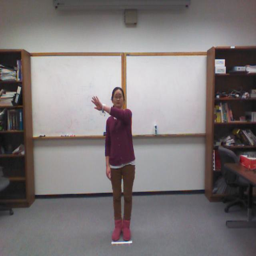

Question: What action is the person performing?
Model output: I can see a person standing in a room with a whiteboard and bookshelves. They are wearing a maroon sweater and brown pants. The person has their right arm extended forward, with their hand open and slightly raised, as if gesturing or pointing. The left arm is bent at the elbow and held closer to the body. The person's head is slightly tilted, and they are looking towards the camera. The room appears to be a classroom or office.

Based on these observations, the person is likely performing a gesture, possibly to indicate something or to communicate.

Answer: gesturing
Extracted: gesturing
Ground truth: swipe left
Correct: False | Format: True
------------------------------------------------------------


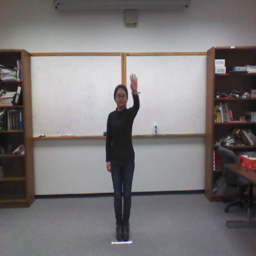

Question: What action is the person performing?
Model output: I can see a person standing in a room with a whiteboard and bookshelves. The person is wearing a black shirt and jeans, and has their right arm raised with the palm facing forward. This gesture is commonly associated with waving.

Answer: waving
Extracted: waving
Ground truth: swipe right
Correct: False | Format: True
------------------------------------------------------------


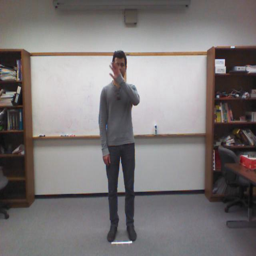

Question: What action is the person performing?
Model output: The person is making a hand gesture with their right hand raised, as if to signal or communicate. The gesture appears to be a common sign for "stop" or "halt" in some contexts, but given the context of a classroom, it's more likely a non-verbal communication, possibly a signal for silence or a pause.

Answer: gesture
Extracted: gesture
Ground truth: wave
Correct: False | Format: True
------------------------------------------------------------


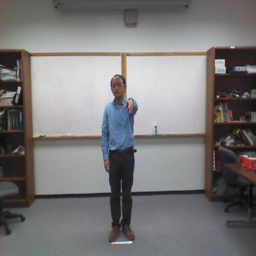

Question: What action is the person performing?
Model output: I can see a person standing in a classroom-like setting with a whiteboard behind them. The person is wearing a light blue shirt and dark pants. They are holding their right arm out, with their hand extended forward and pointing. The posture and gesture suggest they are actively indicating something, likely towards the whiteboard or an audience.

The person is pointing.

Answer: pointing
Extracted: pointing
Ground truth: throw
Correct: False | Format: True
------------------------------------------------------------

Summary: Accuracy=0.0%, Format compliance=100.0% (4 samples)


In [ ]:
import io, requests
from PIL import Image
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# Replace with your own test samples, or use the defaults below.
# Each entry needs an image path (local file) or URL, a question, and ground truth.
TEST_SAMPLES = [
    {
        "image": "/content/mmai-data/images/a1_s2_t1_color.jpg",
        "question": "What action is the person performing?",
        "answer": "swipe left",
    },
    {
        "image": "/content/mmai-data/images/a2_s4_t1_color.jpg",
        "question": "What action is the person performing?",
        "answer": "swipe right",
    },
    {
        "image": "/content/mmai-data/images/a3_s6_t1_color.jpg",
        "question": "What action is the person performing?",
        "answer": "wave",
    },
    {
        "image": "/content/mmai-data/images/a5_s8_t1_color.jpg",
        "question": "What action is the person performing?",
        "answer": "throw",
    },
]

MAX_NEW_TOKENS = 256

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer as a single word on the last line after \"Answer:\". "
    "For example:\nI can see a furry animal curled up on the couch...\nAnswer: cat"
)

def load_image(source: str) -> Image.Image:
    """Load image from a local path or URL."""
    if source.startswith("http://") or source.startswith("https://"):
        response = requests.get(source, stream=True)
        return Image.open(io.BytesIO(response.content)).convert("RGB")
    else:
        return Image.open(source).convert("RGB")

results = []

for sample in TEST_SAMPLES:
    try:
        image = load_image(sample["image"])
    except Exception as e:
        print(f"Could not load image {sample['image']}: {e}")
        continue

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": sample["question"] + INSTRUCTION_SUFFIX},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[image], text=[text], return_tensors="pt", padding=True).to(ft_model.device)

    with torch.no_grad():
        output_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, temperature=0.7, do_sample=True)

    generated = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    extracted = extract_answer(generated)

    results.append({
        "image": sample["image"],
        "question": sample["question"],
        "model_output": generated,
        "extracted_answer": extracted,
        "ground_truth": sample["answer"],
        "correct": (extracted is not None) and (extracted.lower().strip() == sample["answer"].lower().strip()),
        "has_format": extracted is not None,
    })

    display(image.resize((256, 256)))
    print(f"Question: {sample['question']}")
    print(f"Model output: {generated}")
    print(f"Extracted: {extracted}")
    print(f"Ground truth: {sample['answer']}")
    print(f"Correct: {results[-1]['correct']} | Format: {results[-1]['has_format']}")
    print("-" * 60)

n = len(results)
if n > 0:
    acc = sum(r["correct"] for r in results) / n
    fmt = sum(r["has_format"] for r in results) / n
    print(f"\nSummary: Accuracy={acc:.1%}, Format compliance={fmt:.1%} ({n} samples)")

## Problem 8.3: Reflection (5 points)

Compare the GRPO-trained model with the pre-trained base model (zero-shot) and your SFT model from HW3:
- Does the GRPO model use the `Answer:` format more consistently?
- Does it show step-by-step reasoning before the answer?

The GRPO-trained model achieved 0% accuracy but 100% format compliance on the four held-out images. This pattern is consistent with the training dynamics observed in Problem 7, where format reward converged to 1.0 rapidly while accuracy reward remained near zero throughout training.

Compared to the pre-trained base model, the GRPO model shows one clear improvement: it reliably produces structured outputs with step-by-step reasoning followed by an Answer: marker, a behavior the base model did not exhibit. This confirms that RL training successfully shaped the output format through the format reward signal.

However, compared to the SFT model from HW3, GRPO did not improve classification accuracy. Both approaches struggled with the same fundamental limitation: single static frames are insufficient to distinguish visually similar actions. The key difference is that SFT at least occasionally produced correct predictions by memorizing training examples, whereas GRPO never received enough positive accuracy reward signal to learn meaningful action discrimination.

This outcome reinforces the conclusion from Problem 7: GRPO is a poor fit for closed-set classification tasks where random exploration rarely produces correct answers. The format reward alone is not sufficient to drive task performance. A more productive application of GRPO for this dataset would require either richer reward shaping, such as partial credit for semantically related actions, or a fundamentally different input representation that preserves temporal motion information.

The GRPO model does consistently produce step-by-step reasoning before the final answer, describing visual observations such as body posture and arm position before committing to a label. However, this reasoning does not reliably lead to correct conclusions, suggesting that the model learned the reasoning format as a surface behavior rather than developing genuine visual inference capability.

Additionally, the GRPO model occasionally produces outputs outside the defined label space, such as "gesturing" or other free-form descriptions, rather than selecting from the 27 action categories. This reflects a key limitation of the rule-based accuracy reward: since it only rewards exact matches, and exact matches are extremely rare, the model receives almost no signal to constrain its output vocabulary to the label space. SFT does not have this problem because it directly trains on ground truth labels at every step.